In [1]:
!pip install -q PyPDF2 nltk scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.3 MB/s eta 0:00:00


In [2]:
import re, string
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
print("Setup complete")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Setup complete


In [3]:
from google.colab import files
uploaded = files.upload()


Saving resume_ali.txt to resume_ali.txt
Saving resume_ayesha.txt to resume_ayesha.txt
Saving resume_bilal.txt to resume_bilal.txt
Saving resume_sara.txt to resume_sara.txt
Saving resume_usman.txt to resume_usman.txt


In [4]:
import PyPDF2, io

def extract_text_from_pdf(file_bytes):
    reader = PyPDF2.PdfReader(io.BytesIO(file_bytes))
    text = ""
    for page in reader.pages:
        text += (page.extract_text() or "") + "\n"
    return text

resumes = {}
try:
    for fname, content in uploaded.items():
        name = fname.rsplit('.', 1)[0].replace('_', ' ').title()
        if fname.lower().endswith('.pdf'):
            resumes[name] = extract_text_from_pdf(content)
        else:
            resumes[name] = content.decode('utf-8', errors='ignore')
    print(f"Loaded {len(resumes)} uploaded resumes")
except NameError:
    resumes = sample_resumes
    print("No uploads found — using sample_resumes instead")


Loaded 5 uploaded resumes


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)

cleaned_resumes = {name: clean_text(text) for name, text in resumes.items()}
pd.DataFrame({"candidate": cleaned_resumes.keys(), "cleaned_preview": [v[:120] for v in cleaned_resumes.values()]})


,candidate,cleaned_preview
0,Resume Ali,ali raza email phone summary motivated python ...
1,Resume Ayesha,ayesha malik email phone summary machine learn...
2,Resume Bilal,bilal ahmed email phone summary fresh graduate...
3,Resume Sara,sara khan email phone summary data scientist y...
4,Resume Usman,usman tariq email phone summary backend develo...


In [6]:
job_description = '''
We are hiring a Python Developer / Data Scientist with strong skills in
Python, Machine Learning, NLP, SQL, Scikit-learn, and REST API development.
Experience with Docker and cloud deployment is a plus.
'''
cleaned_jd = clean_text(job_description)
print(cleaned_jd)


hiring python developer data scientist strong skill python machine learning nlp sql scikit learn rest api development experience docker cloud deployment plus


In [7]:
candidate_names = list(cleaned_resumes.keys())
corpus = [cleaned_jd] + [cleaned_resumes[n] for n in candidate_names]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

jd_vector = tfidf_matrix[0:1]
resume_vectors = tfidf_matrix[1:]

scores = cosine_similarity(jd_vector, resume_vectors).flatten()
results = pd.DataFrame({
    "Candidate": candidate_names,
    "Match Score (%)": [round(s * 100, 2) for s in scores]
}).sort_values("Match Score (%)", ascending=False).reset_index(drop=True)
results.index += 1
results


,Candidate,Match Score (%)
1,Resume Sara,39.26
2,Resume Ayesha,29.81
3,Resume Ali,22.76
4,Resume Usman,10.81
5,Resume Bilal,8.40


In [10]:
MIN_SCORE = 25
shortlisted = results[results["Match Score (%)"] >= MIN_SCORE]
print("Shortlisted candidates:")
shortlisted


Shortlisted candidates:


,Candidate,Match Score (%)
1,Resume Sara,39.26
2,Resume Ayesha,29.81


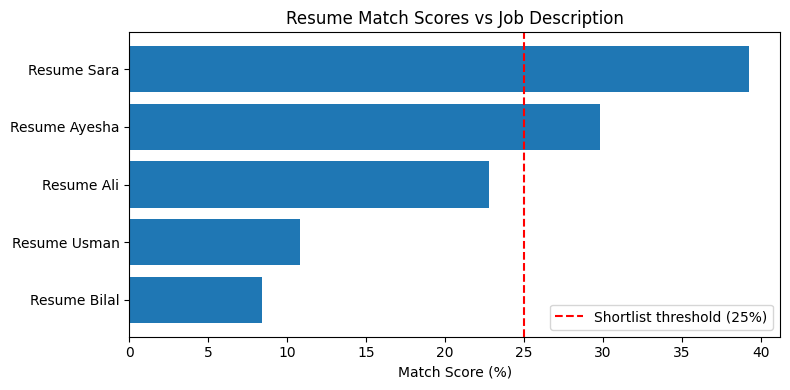

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.barh(results["Candidate"], results["Match Score (%)"])
plt.xlabel("Match Score (%)")
plt.title("Resume Match Scores vs Job Description")
plt.gca().invert_yaxis()
plt.axvline(MIN_SCORE, color='red', linestyle='--', label=f'Shortlist threshold ({MIN_SCORE}%)')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
results.to_csv("resume_screening_results.csv", index=False)
print("Saved resume_screening_results.csv")


Saved resume_screening_results.csv
